In [24]:
import sys
from pathlib import Path

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

sys.path.insert(0, str(Path("..").resolve()))
from utils import (
    ROOT,
    TARGET,
    build_pipeline,
    evaluate_classification,
    get_classification_split,
    load_ml_dataframe,
    make_high_salary_label,
)

MODEL_NAME = "logistic_regression"
ml_df = load_ml_dataframe()
# step 13
X_train, X_test, y_train, y_test = get_classification_split()

print("target column", TARGET, "1 means at or above median salary")
print("low vs high salary in full dataset")
print(make_high_salary_label(ml_df).value_counts(normalize=True).rename({0: "low", 1: "high"}))

pipeline = build_pipeline(
    LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)  # step 13
)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

metrics, report_dict = evaluate_classification(y_test, y_pred)
metrics["model"] = MODEL_NAME

results_df = pd.DataFrame([metrics])
results_df.to_csv(ROOT / "data" / f"results_{MODEL_NAME}.csv", index=False)
results_df


target column ConvertedCompYearly 1 means at or above median salary
low vs high salary in full dataset
ConvertedCompYearly
high    0.686771
low     0.313229
Name: proportion, dtype: float64


,model,accuracy,f1_score,precision_0,recall_0,f1_score_0,support_0,precision_1,recall_1,f1_score_1,support_1
0,logistic_regression,0.598142,0.670243,0.405366,0.605711,0.485689,1821,0.767788,0.594689,0.670243,3992


In [25]:
print(classification_report(y_test, y_pred, target_names=["low", "high"]))

support_table = pd.DataFrame(
    {
        "class": ["low (0)", "high (1)"],
        "support_in_test_set": [
            int((y_test == 0).sum()),
            int((y_test == 1).sum()),
        ],
    }
)
support_table


              precision    recall  f1-score   support

         low       0.41      0.61      0.49      1821
        high       0.77      0.59      0.67      3992

    accuracy                           0.60      5813
   macro avg       0.59      0.60      0.58      5813
weighted avg       0.65      0.60      0.61      5813



,class,support_in_test_set
0,low (0),1821
1,high (1),3992


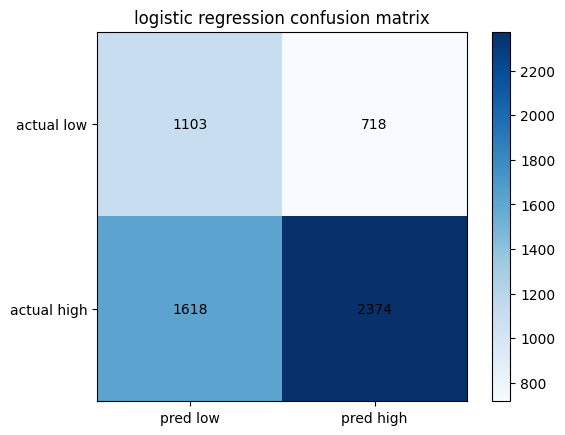

,pred_low,pred_high
actual_low,1103,718
actual_high,1618,2374


In [26]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["actual_low", "actual_high"],
    columns=["pred_low", "pred_high"],
)
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["pred low", "pred high"])
plt.yticks([0, 1], ["actual low", "actual high"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.title("logistic regression confusion matrix")
plt.colorbar()
plt.show()
cm_df